# Project 2 — Notebook 06: Resolution Path Analysis
### NCR Zone-Level Breakdown of How Tickets Are Resolved

---

**Question this notebook answers:**
What proportion of tickets per zone are resolved remotely by NOC (`NOC_Remote_Restored`)
vs dispatched to field (`Field_Dispatch_Restored`) vs self-healed (`Auto_Self_Restored`)?
Does that split explain MTTR and SLA variance between zones?

| Resolution Path | Definition |
|----------------|-----------|
| `Auto_Self_Restored` | Fault cleared without NOC or field intervention |
| `NOC_Remote_Restored` | NOC resolved remotely — no field dispatch required |
| `Field_Dispatch_Restored` | WO issued, field engineer resolved on-site |

> **Data note:** Phase time metrics (NOC/ROC Time, Field Time) are computed on
> `Timestamp_Integrity = True` tickets only. Volume and SLA metrics use all tickets.

## 1. Setup
from fault_ticket_plots import plot_grouped_bar_by_zone

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from src.fault_ticket.metrics import calculate_zone_summary
from config import ZONE_ORDER, ZONE_PALETTE
from src.visualization import plot_grouped_bar_by_zone

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
summary = calculate_zone_summary(df)

ZONE_COLORS = ZONE_PALETTE
PATH_COLORS = {
    'Auto_Self_Restored'    : '#2ca02c',
    'NOC_Remote_Restored'   : '#5b9bd5',
    'Field_Dispatch_Restored': '#ed7d31',
}
PATH_LABELS = {
    'Auto_Self_Restored'    : 'Auto Self-Restored',
    'NOC_Remote_Restored'   : 'NOC Remote',
    'Field_Dispatch_Restored': 'Field Dispatch',
}

print(f"✅ {len(df):,} tickets · {df['ZONE'].nunique()} zones")
print(f"   Resolution_Path values: {df['Resolution_Path'].value_counts().to_dict()}")
print(f"   Timestamp_Integrity clean: {df['Timestamp_Integrity'].sum():,} "
      f"({df['Timestamp_Integrity'].mean()*100:.1f}%)")

✅ 38,319 tickets · 7 zones
   Resolution_Path values: {'Field_Dispatch_Restored': 23239, 'NOC_Remote_Restored': 12299, 'Auto_Self_Restored': 2781}
   Timestamp_Integrity clean: 36,854 (96.2%)


## 2. NCR-Wide Resolution Path Distribution

In [2]:
# Overall split
ncr_split = (df.groupby('Resolution_Path').size()
               .reindex(['Auto_Self_Restored','NOC_Remote_Restored','Field_Dispatch_Restored'])
               .fillna(0)
               .astype(int))
total = ncr_split.sum()

display(Markdown("### NCR Total — Resolution Path Split"))
for path, count in ncr_split.items():
    label = PATH_LABELS[path]
    pct   = count / total * 100
    bar   = '█' * int(pct / 2)
    print(f"  {label:<28} {count:>6,}  ({pct:5.1f}%)  {bar}")

print(f"\n  Total: {total:,} tickets")

### NCR Total — Resolution Path Split

  Auto Self-Restored            2,781  (  7.3%)  ███
  NOC Remote                   12,299  ( 32.1%)  ████████████████
  Field Dispatch               23,239  ( 60.6%)  ██████████████████████████████

  Total: 38,319 tickets


## 3. Resolution Path Split by Zone

In [3]:
# Zone × Resolution_Path crosstab
zone_path = (df[df['ZONE'].isin(ZONE_ORDER)]
             .groupby(['ZONE', 'Resolution_Path'])
             .size()
             .unstack(fill_value=0)
             .reindex(columns=['Auto_Self_Restored','NOC_Remote_Restored','Field_Dispatch_Restored'],
                      fill_value=0))

zone_path_pct = zone_path.div(zone_path.sum(axis=1), axis=0) * 100
zone_path_pct = zone_path_pct.reindex(ZONE_ORDER)
zone_path     = zone_path.reindex(ZONE_ORDER)

# Display table
tbl = zone_path_pct.copy().round(1)
tbl.columns = [PATH_LABELS[c] for c in tbl.columns]
tbl['Total Tickets'] = zone_path.sum(axis=1).astype(int)
for col in [PATH_LABELS[p] for p in PATH_COLORS]:
    tbl[col] = tbl[col].map('{:.1f}%'.format)

display(Markdown("### Resolution Path % by Zone"))
display(tbl.style
    .set_caption('Table 1 — Resolution Path Distribution per Zone')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','12px'),('font-weight','bold'),
                                           ('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),
                                      ('font-size','11px'),('padding','7px 10px')]},
        {'selector': 'td', 'props': [('padding','6px 10px'),('font-size','11px'),('text-align','center')]},
    ])
)

### Resolution Path % by Zone

,Auto Self-Restored,NOC Remote,Field Dispatch,Total Tickets
ZONE,,,,
ZONE 1,1.3%,34.1%,64.6%,4306
ZONE 2,1.6%,35.6%,62.8%,7307
ZONE 3,0.5%,13.4%,86.1%,4393
ZONE 4,11.4%,32.4%,56.2%,7952
ZONE 5,12.8%,34.0%,53.2%,9131
ZONE 6,1.4%,37.2%,61.4%,3818


## 4. Stacked Bar — Path Mix by Zone

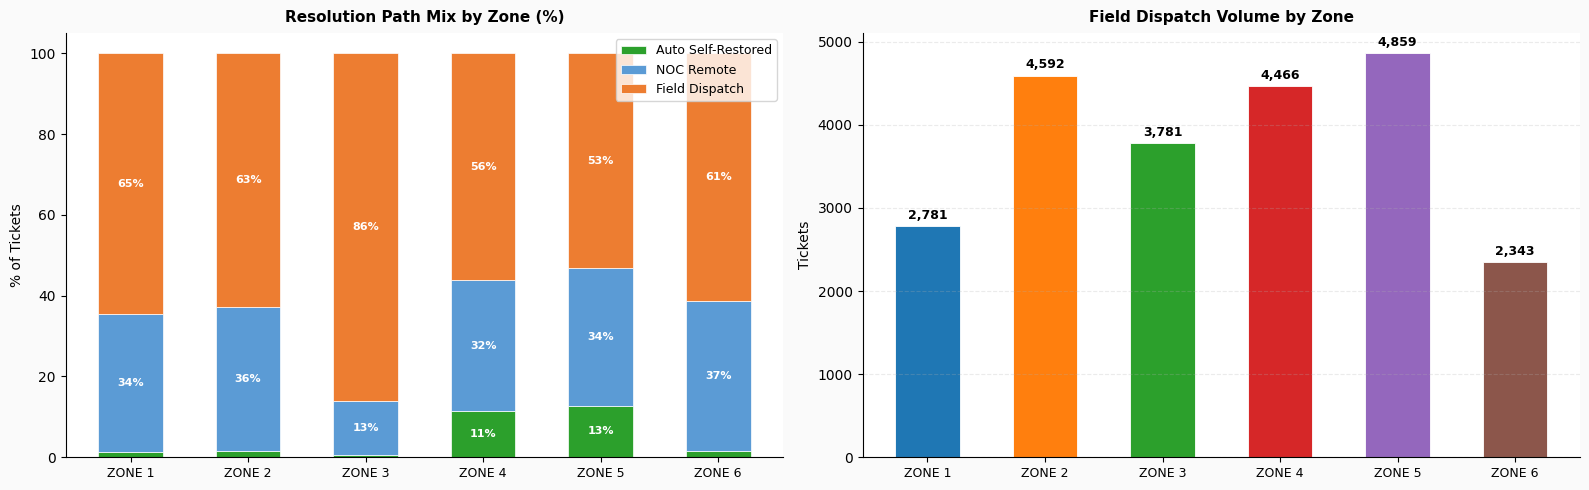

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#fafafa')

paths = ['Auto_Self_Restored', 'NOC_Remote_Restored', 'Field_Dispatch_Restored']
x = np.arange(len(ZONE_ORDER))
w = 0.55

# [Left] Stacked % bar
bottom = np.zeros(len(ZONE_ORDER))
for path in paths:
    vals = zone_path_pct[path].values
    bars = axes[0].bar(x, vals, w, bottom=bottom,
                       color=PATH_COLORS[path], label=PATH_LABELS[path],
                       edgecolor='white', linewidth=0.5)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 4:
            axes[0].text(bar.get_x() + bar.get_width()/2,
                         bot + val/2, f'{val:.0f}%',
                         ha='center', va='center', fontsize=8,
                         fontweight='bold', color='white')
    bottom += vals

axes[0].set_xticks(x)
axes[0].set_xticklabels(ZONE_ORDER, fontsize=9)
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('% of Tickets', fontsize=10)
axes[0].set_title('Resolution Path Mix by Zone (%)', fontsize=11, fontweight='bold', pad=8)
axes[0].legend(fontsize=9, loc='upper right', framealpha=0.8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# [Right] Field dispatch count — absolute volume
fd_counts = zone_path['Field_Dispatch_Restored'].reindex(ZONE_ORDER)
bars = axes[1].bar(x, fd_counts, w,
                   color=[ZONE_COLORS.get(z,'#888') for z in ZONE_ORDER],
                   edgecolor='white', linewidth=0.6)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 50,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ZONE_ORDER, fontsize=9)
axes[1].set_ylabel('Tickets', fontsize=10)
axes[1].set_title('Field Dispatch Volume by Zone', fontsize=11, fontweight='bold', pad=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
os.makedirs('reports/figures/project2_ncr', exist_ok=True)
plt.savefig('reports/figures/project2_ncr/06_resolution_path_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. MTTR by Resolution Path × Zone

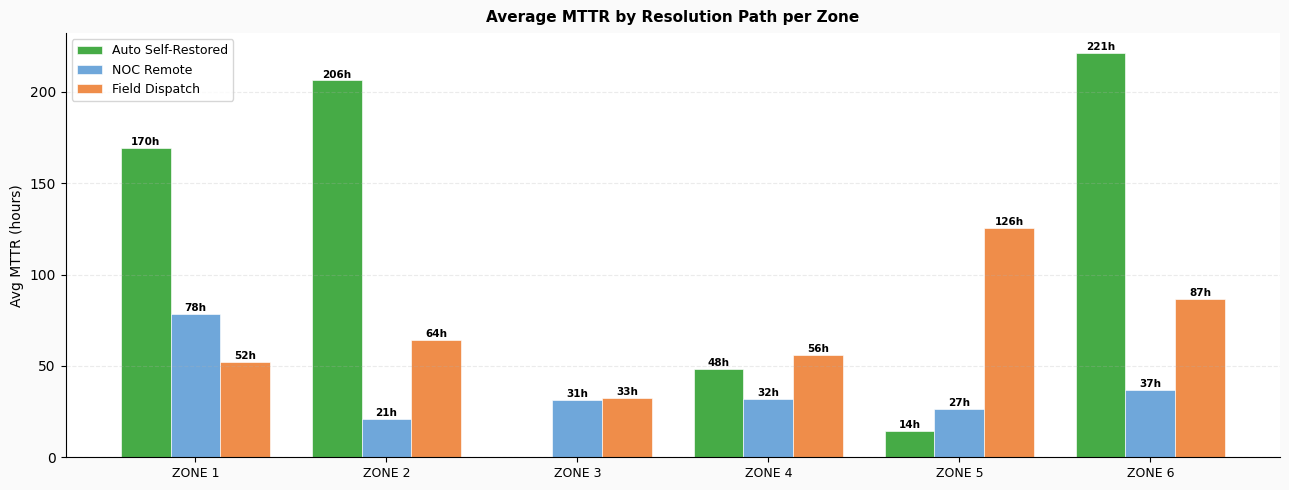


Key observations:
  ZONE 1: Field 52h · NOC Remote 78h
  ZONE 2: Field 64h · NOC Remote 21h
  ZONE 3: Field 33h · NOC Remote 31h
  ZONE 4: Field 56h · NOC Remote 32h
  ZONE 5: Field 126h · NOC Remote 27h
  ZONE 6: Field 87h · NOC Remote 37h


In [5]:
# MTTR split by resolution path per zone
mttr_path = (df[df['ZONE'].isin(ZONE_ORDER)]
             .groupby(['ZONE', 'Resolution_Path'])['OUTAGEDURATION']
             .mean()
             .unstack(fill_value=0)
             .reindex(columns=paths, fill_value=0)
             .reindex(ZONE_ORDER))

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')
plot_grouped_bar_by_zone(
    ax, mttr_path, ZONE_ORDER,
    col_order  = paths,
    col_colors = [PATH_COLORS[p] for p in paths],
    col_labels = [PATH_LABELS[p] for p in paths],
    ylabel='Avg MTTR (hours)',
    title='Average MTTR by Resolution Path per Zone',
    fmt='{:.0f}h',
)
plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/06_mttr_by_path.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observations:")
for zone in ZONE_ORDER:
    if zone not in mttr_path.index: continue
    fd = mttr_path.loc[zone, 'Field_Dispatch_Restored']
    nr = mttr_path.loc[zone, 'NOC_Remote_Restored']
    print(f"  {zone}: Field {fd:.0f}h · NOC Remote {nr:.0f}h")


## 6. SLA Compliance by Resolution Path × Zone

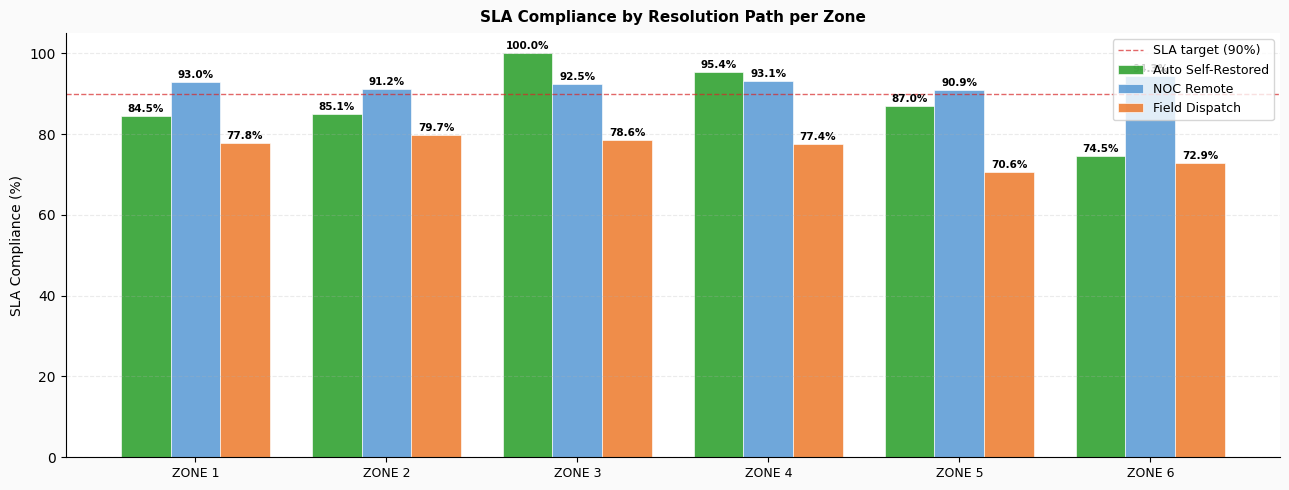

In [6]:
sla_path = (df[df['ZONE'].isin(ZONE_ORDER)]
             .groupby(['ZONE', 'Resolution_Path'])['SLA_Compliant']
             .mean().mul(100)
             .unstack(fill_value=0)
             .reindex(columns=paths, fill_value=0)
             .reindex(ZONE_ORDER))

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')
plot_grouped_bar_by_zone(
    ax, sla_path, ZONE_ORDER,
    col_order  = paths,
    col_colors = [PATH_COLORS[p] for p in paths],
    col_labels = [PATH_LABELS[p] for p in paths],
    ylabel='SLA Compliance (%)',
    title='SLA Compliance by Resolution Path per Zone',
    fmt='{:.1f}%', annotate_threshold=2,
)
ax.axhline(90, color='#d62728', linestyle='--', linewidth=1, alpha=0.7, label='SLA target (90%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9, framealpha=0.8)
plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/06_sla_by_path.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Field Time Distribution — Field Dispatch Tickets Only

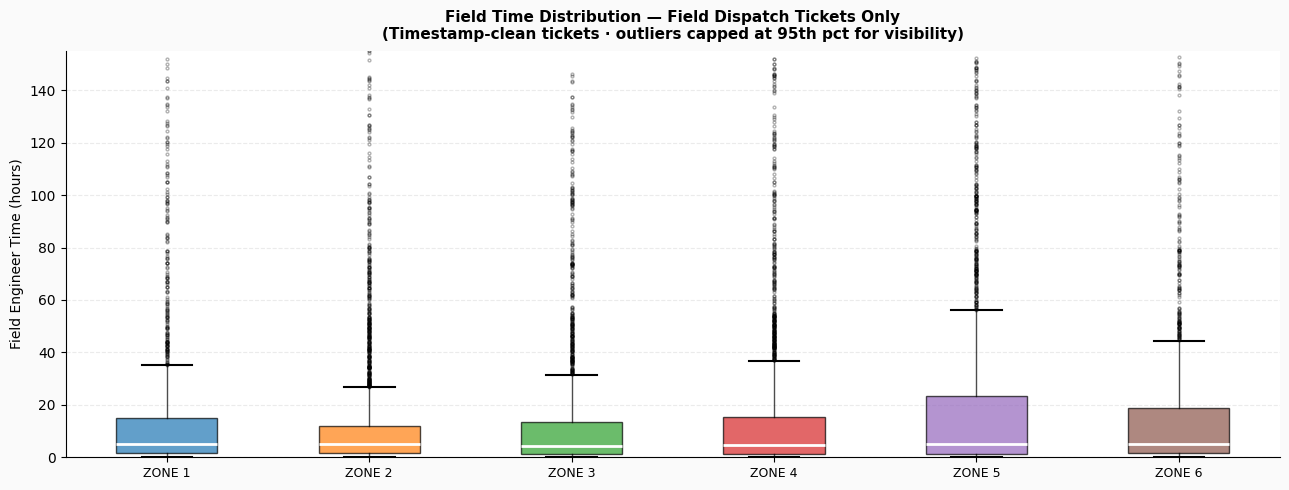


Field Time stats (Field Dispatch · clean timestamps):
        Median   Mean     Std   P75
ZONE                               
ZONE 1     5.0   53.4   394.5  15.0
ZONE 2     4.9   66.3  1485.3  11.8
ZONE 3     4.4   33.7   221.3  13.5
ZONE 4     4.7   58.6   463.8  15.5
ZONE 5     5.0  131.8   680.7  23.2
ZONE 6     5.2   89.1   577.7  18.8


In [7]:
# For Field_Dispatch_Restored tickets with clean timestamps —
# how is field time distributed per zone? Boxplot shows spread, not just mean.
clean_fd = df[
    (df['Resolution_Path'] == 'Field_Dispatch_Restored') &
    (df['ZONE'].isin(ZONE_ORDER)) &
    (df['Timestamp_Integrity'])
].copy()

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')

zone_data = [clean_fd[clean_fd['ZONE'] == z]['FIELD_TIME_HOURS'].dropna().values
             for z in ZONE_ORDER]
bp = ax.boxplot(zone_data, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1, alpha=0.7),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=2, alpha=0.3),
                widths=0.5)

for patch, zone in zip(bp['boxes'], ZONE_ORDER):
    patch.set_facecolor(ZONE_COLORS.get(zone, '#888'))
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(ZONE_ORDER) + 1))
ax.set_xticklabels(ZONE_ORDER, fontsize=9)
ax.set_ylabel('Field Engineer Time (hours)', fontsize=10)
ax.set_title('Field Time Distribution — Field Dispatch Tickets Only\n(Timestamp-clean tickets · outliers capped at 95th pct for visibility)',
             fontsize=11, fontweight='bold', pad=8)

# Cap y-axis at 95th percentile for readability
cap = clean_fd['FIELD_TIME_HOURS'].quantile(0.95)
ax.set_ylim(0, cap * 1.1)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/06_field_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nField Time stats (Field Dispatch · clean timestamps):")
print(clean_fd.groupby('ZONE')['FIELD_TIME_HOURS']
      .agg(['median','mean','std',lambda x: x.quantile(0.75)])
      .rename(columns={'median':'Median','mean':'Mean','std':'Std','<lambda_0>':'P75'})
      .reindex(ZONE_ORDER)
      .round(1)
      .to_string())

## 8. Operational Interpretation

In [8]:
# Summary findings table
findings = pd.DataFrame({
    'ZONE'       : ZONE_ORDER,
    'Field_Dispatch_%' : [zone_path_pct.loc[z, 'Field_Dispatch_Restored'] for z in ZONE_ORDER],
    'NOC_Remote_%'     : [zone_path_pct.loc[z, 'NOC_Remote_Restored']    for z in ZONE_ORDER],
    'Auto_%'           : [zone_path_pct.loc[z, 'Auto_Self_Restored']      for z in ZONE_ORDER],
    'Field_MTTR'       : [mttr_path.loc[z, 'Field_Dispatch_Restored']     for z in ZONE_ORDER],
    'NOC_MTTR'         : [mttr_path.loc[z, 'NOC_Remote_Restored']         for z in ZONE_ORDER],
    'Field_SLA'        : [sla_path.loc[z, 'Field_Dispatch_Restored']      for z in ZONE_ORDER],
})

display(Markdown("### Summary — Resolution Path KPIs by Zone"))
display(findings.style
    .hide(axis='index')
    .format({
        'Field_Dispatch_%': '{:.1f}%',
        'NOC_Remote_%'    : '{:.1f}%',
        'Auto_%'          : '{:.1f}%',
        'Field_MTTR'      : '{:.0f}h',
        'NOC_MTTR'        : '{:.0f}h',
        'Field_SLA'        : '{:.1f}%',
    })
    .background_gradient(subset=['Field_Dispatch_%'], cmap='Oranges', vmin=50, vmax=100)
    .background_gradient(subset=['Field_MTTR'],       cmap='RdYlGn_r', vmin=30, vmax=100)
    .background_gradient(subset=['Field_SLA'],        cmap='RdYlGn',   vmin=80, vmax=95)
    .set_caption('Table 2 — Resolution Path KPI Summary')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','12px'),('font-weight','bold'),
                                           ('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),
                                      ('font-size','11px'),('padding','7px 10px')]},
        {'selector': 'td', 'props': [('padding','6px 10px'),('font-size','11px'),('text-align','center')]},
    ])
)

### Summary — Resolution Path KPIs by Zone

ZONE,Field_Dispatch_%,NOC_Remote_%,Auto_%,Field_MTTR,NOC_MTTR,Field_SLA
ZONE 1,64.6%,34.1%,1.3%,52h,78h,77.8%
ZONE 2,62.8%,35.6%,1.6%,64h,21h,79.7%
ZONE 3,86.1%,13.4%,0.5%,33h,31h,78.6%
ZONE 4,56.2%,32.4%,11.4%,56h,32h,77.4%
ZONE 5,53.2%,34.0%,12.8%,126h,27h,70.6%
ZONE 6,61.4%,37.2%,1.4%,87h,37h,72.9%


## 9. Next Steps

→ **Notebook 07** — Fault Anatomy: RFO distribution and NE Category breakdown by zone.